# Algorithmic Trading Project

This notebook downloads 1-hour OHLCV data from Binance for `BTCUSDT`, `ETHUSDT`, and an optional altcoin (`DOGEUSDT` by default), stores the raw market data in Parquet, audits data quality, constructs excess simple returns using the previous-step risk-free rate, flags return outliers with a rolling z-score filter, and displays the flagged rows without altering the original candles.

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from datetime import datetime, timezone
from IPython.display import display
import ccxt
from dotenv import load_dotenv
load_dotenv()

True

In [114]:
SYMBOLS    = ["BTC/USDT", "ETH/USDT", "DOGE/USDT", "SOL/USDT"]
TIMEFRAME  = "1h"
SINCE      = "2024-06-01"
DATA_DIR   = Path("data")

In [115]:
exchange = ccxt.binance()
since_ms = exchange.parse8601(f"{SINCE}T00:00:00Z")


def write_parquet_safe(df: pd.DataFrame, path: Path) -> None:
    import pyarrow as pa
    import pyarrow.parquet as pq

    # Ensure destination folder exists before writing parquet.
    path.parent.mkdir(parents=True, exist_ok=True)

    # Bypass pandas' parquet wrapper, which can trip over Arrow extension
    # registration when notebook cells are re-run in the same kernel.
    table = pa.Table.from_pandas(df, preserve_index=True)
    pq.write_table(table, path)


for symbol in SYMBOLS:
    print(f"Downloading {symbol}...", end="", flush=True)

    all_bars = []
    since    = since_ms

    while True:
        bars = exchange.fetch_ohlcv(symbol, timeframe=TIMEFRAME,
                                    since=since, limit=1000)
        if not bars:
            break
        all_bars.extend(bars)
        since = bars[-1][0] + 1
        print(".", end="", flush=True)
        time.sleep(0.3)

        now_ms = datetime.now(timezone.utc).timestamp() * 1000
        if bars[-1][0] >= now_ms - 3_600_000:
            break

    df = pd.DataFrame(all_bars,
                      columns=["timestamp", "open", "high", "low",
                                "close", "volume"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("timestamp").sort_index()

    fname = DATA_DIR / f"{symbol.replace('/', '')}_1h.parquet"
    write_parquet_safe(df, fname)
    print(f" {len(df):,} bars → {fname}")

print("\nDone.")


Done.


### Macro Data — Effective Fed Funds Rate (FRED)

In [116]:
import os
from fredapi import Fred

# Set FRED_API_KEY in your environment before running this cell.
fred = Fred(api_key=os.environ["FRED_API_KEY"])

dff = fred.get_series("DFF", observation_start=SINCE)
dff = dff.rename("fed_funds_rate").rename_axis("date")
dff.index = pd.to_datetime(dff.index, utc=True)

dff_path = DATA_DIR / "DFF_daily.parquet"
dff.to_frame().to_parquet(dff_path, engine="pyarrow")
print(f"Fed Funds Rate: {len(dff):,} observations → {dff_path}")
dff.tail()

Fed Funds Rate: 655 observations → data/DFF_daily.parquet


date
2026-03-13 00:00:00+00:00    3.64
2026-03-14 00:00:00+00:00    3.64
2026-03-15 00:00:00+00:00    3.64
2026-03-16 00:00:00+00:00    3.64
2026-03-17 00:00:00+00:00    3.64
Name: fed_funds_rate, dtype: float64

### Data Cleaning

In [117]:
PROCESSED_DIR = DATA_DIR / "processed" / "binance"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

VALUE_COLUMNS = ["open", "high", "low", "close", "volume"]
RF_PATH = DATA_DIR / "DFF_daily.parquet"
HOURS_PER_YEAR = 24 * 365


def read_parquet_safe(path: Path) -> pd.DataFrame:
    import pyarrow.parquet as pq

    table = pq.read_table(path)
    return table.to_pandas()


def load_hourly_risk_free_rate(path: Path) -> pd.Series:
    rf_frame = read_parquet_safe(path)

    if isinstance(rf_frame, pd.Series):
        rf_series = rf_frame.rename("fed_funds_rate")
    elif "fed_funds_rate" in rf_frame.columns:
        rf_series = rf_frame["fed_funds_rate"]
    elif rf_frame.shape[1] == 1:
        rf_series = rf_frame.iloc[:, 0].rename("fed_funds_rate")
    else:
        raise ValueError(f"Could not identify the risk-free column in {path}")

    rf_index = pd.DatetimeIndex(rf_series.index)
    if rf_index.tz is None:
        rf_index = rf_index.tz_localize("UTC")
    else:
        rf_index = rf_index.tz_convert("UTC")

    rf_series.index = rf_index
    rf_series = rf_series.sort_index().astype(float)

    # DFF is quoted in annualized percent, so convert it to an hourly simple rate.
    return ((1.0 + rf_series.div(100.0)).pow(1.0 / HOURS_PER_YEAR) - 1.0).rename("risk_free_rate")


def audit_ohlcv(df: pd.DataFrame, symbol: str, stage: str) -> dict:
    audit_frame = df.sort_index().copy()
    index = pd.DatetimeIndex(audit_frame.index)

    if index.tz is None:
        index = index.tz_localize("UTC")
    else:
        index = index.tz_convert("UTC")

    audit_frame.index = index
    expected_index = pd.date_range(index.min(), index.max(), freq=TIMEFRAME, tz="UTC")
    gap_hours = index.to_series().diff().dropna().div(pd.Timedelta(hours=1))

    high_low_violations = (audit_frame["high"] < audit_frame["low"]).fillna(False)
    candle_rule_violations = (
        (audit_frame["high"] < audit_frame[["open", "close"]].max(axis=1))
        | (audit_frame["low"] > audit_frame[["open", "close"]].min(axis=1))
    ).fillna(False)

    return {
        "symbol": symbol,
        "stage": stage,
        "rows": len(audit_frame),
        "start": index.min(),
        "end": index.max(),
        "duplicate_timestamps": int(index.duplicated().sum()),
        "missing_bars": int(len(expected_index.difference(index))),
        "null_rows": int(audit_frame[VALUE_COLUMNS].isna().any(axis=1).sum()),
        "null_values": int(audit_frame[VALUE_COLUMNS].isna().sum().sum()),
        "non_positive_price_rows": int((audit_frame[["open", "high", "low", "close"]] <= 0).any(axis=1).sum()),
        "negative_volume_rows": int((audit_frame["volume"] < 0).sum()),
        "zero_volume_rows": int((audit_frame["volume"] == 0).sum()),
        "high_below_low_rows": int(high_low_violations.sum()),
        "candle_rule_violations": int(candle_rule_violations.sum()),
        "max_gap_hours": float(gap_hours.max()) if not gap_hours.empty else 0.0,
        "outliers_flagged": int(audit_frame["is_outlier"].sum()) if "is_outlier" in audit_frame else 0,
        "missing_bar_rows": int(audit_frame["missing_bar"].sum()) if "missing_bar" in audit_frame else 0,
    }


def flag_ohlcv_outliers(
    df: pd.DataFrame,
    risk_free_rate: pd.Series,
    rolling_window: int = 72,
    zscore_threshold: float = 5.0,
) -> pd.DataFrame:
    flagged = df.sort_index().copy()
    flagged.index = pd.DatetimeIndex(flagged.index)

    if flagged.index.tz is None:
        flagged.index = flagged.index.tz_localize("UTC")
    else:
        flagged.index = flagged.index.tz_convert("UTC")

    flagged.index.name = "timestamp"
    flagged["missing_bar"] = False
    flagged["simple_return"] = flagged["close"].pct_change()

    aligned_rf = risk_free_rate.reindex(flagged.index, method="ffill")
    flagged["risk_free_rate"] = aligned_rf.shift(1)
    flagged["excess_simple_return"] = flagged["simple_return"] - flagged["risk_free_rate"]

    min_periods = max(rolling_window // 3, 12)
    rolling_returns = flagged["excess_simple_return"].rolling(window=rolling_window, min_periods=min_periods)
    rolling_std = rolling_returns.std(ddof=0).replace(0.0, np.nan)
    flagged["return_zscore"] = (flagged["excess_simple_return"] - rolling_returns.mean()) / rolling_std
    flagged["is_outlier"] = flagged["return_zscore"].abs().gt(zscore_threshold).fillna(False)
    flagged["clean_return"] = flagged["excess_simple_return"]
    return flagged


risk_free_rate = load_hourly_risk_free_rate(RF_PATH)

flagged_frames = {}
quality_rows = []
flagged_rows = []

for symbol in SYMBOLS:
    raw_path = DATA_DIR / f"{symbol.replace('/', '')}_{TIMEFRAME}.parquet"
    raw_df = read_parquet_safe(raw_path)
    raw_df.index = pd.DatetimeIndex(raw_df.index)

    quality_rows.append(audit_ohlcv(raw_df, symbol, "raw"))

    flagged_df = flag_ohlcv_outliers(raw_df, risk_free_rate=risk_free_rate)
    flagged_path = PROCESSED_DIR / f"{symbol.replace('/', '')}_{TIMEFRAME}_flagged.parquet"
    write_parquet_safe(flagged_df, flagged_path)

    flagged_frames[symbol] = flagged_df
    quality_rows.append(audit_ohlcv(flagged_df, symbol, "flagged"))

    symbol_flags = flagged_df.loc[
        flagged_df["is_outlier"],
        [
            "open",
            "high",
            "low",
            "close",
            "volume",
            "simple_return",
            "risk_free_rate",
            "excess_simple_return",
            "return_zscore",
        ],
    ].copy()
    symbol_flags.insert(0, "symbol", symbol)
    flagged_rows.append(symbol_flags.reset_index())

quality_report = pd.DataFrame(quality_rows).sort_values(["symbol", "stage"]).reset_index(drop=True)
display(quality_report)

post_clean_checks = quality_report.loc[
    quality_report["stage"] == "flagged",
    [
        "symbol",
        "missing_bars",
        "null_rows",
        "non_positive_price_rows",
        "negative_volume_rows",
        "high_below_low_rows",
        "candle_rule_violations",
        "outliers_flagged",
    ],
]
display(post_clean_checks)

flagged_outliers = pd.concat(flagged_rows, ignore_index=True).sort_values(["symbol", "timestamp"])
display(flagged_outliers)


,symbol,stage,rows,start,end,duplicate_timestamps,missing_bars,null_rows,null_values,non_positive_price_rows,negative_volume_rows,zero_volume_rows,high_below_low_rows,candle_rule_violations,max_gap_hours,outliers_flagged,missing_bar_rows
0,BTC/USDT,flagged,15763,2024-06-01 00:00:00+00:00,2026-03-19 18:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,27,0
1,BTC/USDT,raw,15763,2024-06-01 00:00:00+00:00,2026-03-19 18:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0
2,DOGE/USDT,flagged,15763,2024-06-01 00:00:00+00:00,2026-03-19 18:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,27,0
3,DOGE/USDT,raw,15763,2024-06-01 00:00:00+00:00,2026-03-19 18:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0
4,ETH/USDT,flagged,15763,2024-06-01 00:00:00+00:00,2026-03-19 18:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,37,0
5,ETH/USDT,raw,15763,2024-06-01 00:00:00+00:00,2026-03-19 18:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0
6,SOL/USDT,flagged,15763,2024-06-01 00:00:00+00:00,2026-03-19 18:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,23,0
7,SOL/USDT,raw,15763,2024-06-01 00:00:00+00:00,2026-03-19 18:00:00+00:00,0,0,0,0,0,0,0,0,0,1.0,0,0


,symbol,missing_bars,null_rows,non_positive_price_rows,negative_volume_rows,high_below_low_rows,candle_rule_violations,outliers_flagged
0,BTC/USDT,0,0,0,0,0,0,27
2,DOGE/USDT,0,0,0,0,0,0,27
4,ETH/USDT,0,0,0,0,0,0,37
6,SOL/USDT,0,0,0,0,0,0,23


,timestamp,symbol,open,high,low,close,volume,simple_return,risk_free_rate,excess_simple_return,return_zscore
0,2024-06-12 12:00:00+00:00,BTC/USDT,67778.43,69488.00,67736.00,69339.29,5379.40042,0.023029,0.000006,0.023023,5.684964
1,2024-06-24 09:00:00+00:00,BTC/USDT,62730.92,62867.00,60567.01,61402.28,6567.42005,-0.021180,0.000006,-0.021186,-5.529886
2,2024-07-04 01:00:00+00:00,BTC/USDT,60430.01,60498.19,58444.00,58561.10,5938.30437,-0.030927,0.000006,-0.030933,-5.732817
3,2024-07-08 08:00:00+00:00,BTC/USDT,55852.00,57891.81,55741.11,57792.00,4740.11500,0.034734,0.000006,0.034729,5.115356
4,2024-08-12 14:00:00+00:00,BTC/USDT,58157.55,60711.09,57800.00,60299.98,5156.24546,0.036838,0.000006,0.036832,5.208797
...,...,...,...,...,...,...,...,...,...,...,...
109,2025-12-01 00:00:00+00:00,SOL/USDT,133.48,133.74,127.53,127.57,958104.52600,-0.044276,0.000004,-0.044281,-5.104471
110,2025-12-15 15:00:00+00:00,SOL/USDT,130.48,130.60,126.45,126.89,713478.62400,-0.027588,0.000004,-0.027592,-5.150818
111,2026-01-18 23:00:00+00:00,SOL/USDT,142.86,142.86,137.74,137.87,407539.60100,-0.034929,0.000004,-0.034933,-6.468612
112,2026-01-25 19:00:00+00:00,SOL/USDT,121.69,121.87,117.15,117.96,959971.67700,-0.030652,0.000004,-0.030656,-5.205040


### Excess Return Time Series

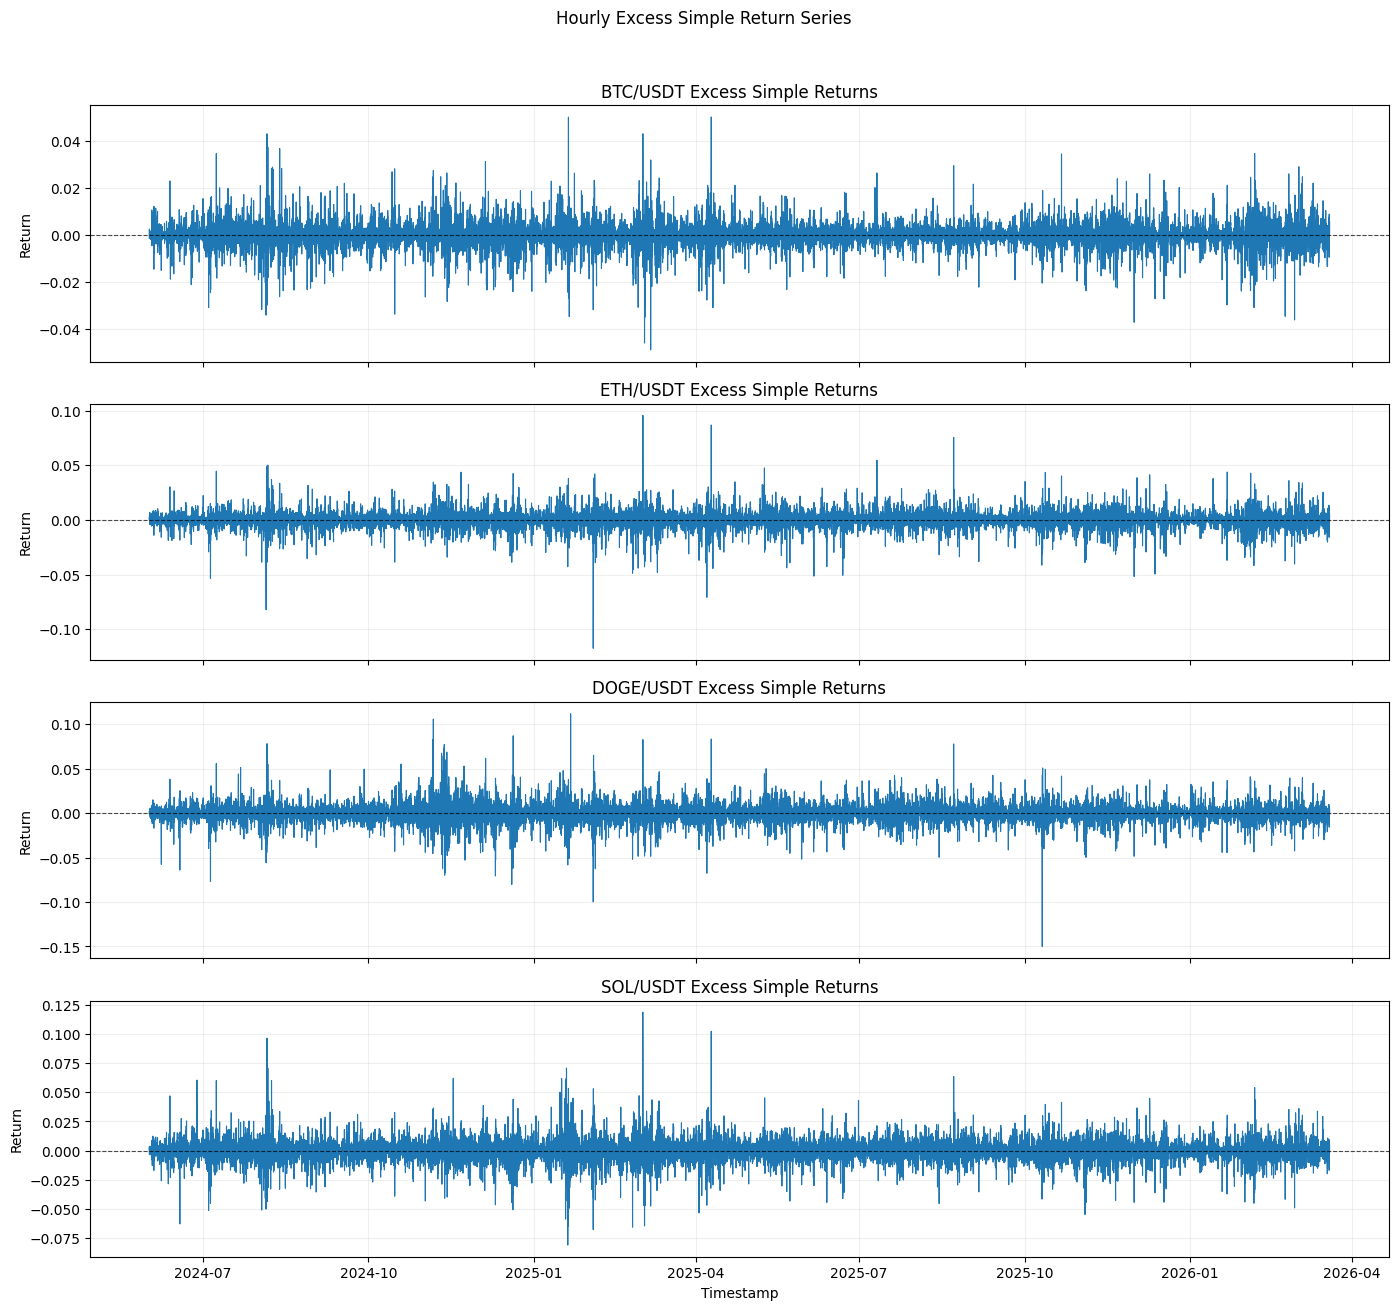

In [118]:
fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(14, 3.2 * len(SYMBOLS)), sharex=True)

if len(SYMBOLS) == 1:
    axes = [axes]

for ax, symbol in zip(axes, SYMBOLS):
    plot_frame = flagged_frames[symbol]
    ax.plot(plot_frame.index, plot_frame["excess_simple_return"], lw=0.8, color="tab:blue")
    ax.axhline(0.0, color="black", lw=0.8, ls="--", alpha=0.7)
    ax.set_title(f"{symbol} Excess Simple Returns")
    ax.set_ylabel("Return")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Timestamp")
fig.suptitle("Hourly Excess Simple Return Series", y=1.02)
fig.tight_layout()
plt.show()


## Pair Diagnostics: Cointegration Tests (All Pairs)

In [119]:
from itertools import combinations
from statsmodels.tsa.vector_ar.vecm import coint_johansen


def infer_rank_95(test_stats: np.ndarray, critical_values_95: np.ndarray) -> int:
    rejections = list(test_stats > critical_values_95)

    if rejections[0] and not rejections[1]:
        return 1
    if not rejections[0]:
        return 0
    return 2


def interpret_pair_result(trace_rank_95: int, maxeig_rank_95: int) -> str:
    if trace_rank_95 == 1 and maxeig_rank_95 == 1:
        return (
            "Confirmed rank-1 cointegration. Both Johansen tests support one stationary "
            "spread, which is the standard setup for pairs trading."
        )
    if trace_rank_95 == 0 and maxeig_rank_95 == 0:
        return (
            "No cointegration evidence at 95%. The data do not support a mean-reverting "
            "spread for this pair under the current specification."
        )
    if trace_rank_95 != maxeig_rank_95:
        return (
            "Mixed evidence. The trace and max-eigenvalue tests disagree, so this pair "
            "should be treated as inconclusive rather than tradable."
        )
    return (
        "Non-standard outcome. Rank 2 in a two-asset system suggests the prices may be "
        "stationary already or the model specification is not appropriate for pairs trading."
    )


pair_results = {}
summary_rows = []

for left_symbol, right_symbol in combinations(SYMBOLS, 2):
    pair_name = f"{left_symbol} vs {right_symbol}"
    pair_prices = pd.concat(
        [
            flagged_frames[left_symbol]["close"].rename(left_symbol),
            flagged_frames[right_symbol]["close"].rename(right_symbol),
        ],
        axis=1,
    ).dropna()

    log_prices = np.log(pair_prices)
    johansen_result = coint_johansen(log_prices, det_order=0, k_ar_diff=1)

    trace_table = pd.DataFrame(
        {
            "rank_null": [f"r <= {i}" for i in range(log_prices.shape[1])],
            "trace_stat": johansen_result.lr1,
            "crit_95": johansen_result.cvt[:, 1],
        }
    )
    trace_table["reject_95"] = trace_table["trace_stat"] > trace_table["crit_95"]

    maxeig_table = pd.DataFrame(
        {
            "rank_null": [f"r = {i}" for i in range(log_prices.shape[1])],
            "maxeig_stat": johansen_result.lr2,
            "crit_95": johansen_result.cvm[:, 1],
        }
    )
    maxeig_table["reject_95"] = maxeig_table["maxeig_stat"] > maxeig_table["crit_95"]

    trace_rank_95 = infer_rank_95(johansen_result.lr1, johansen_result.cvt[:, 1])
    maxeig_rank_95 = infer_rank_95(johansen_result.lr2, johansen_result.cvm[:, 1])
    cointegration_confirmed_95 = trace_rank_95 == 1 and maxeig_rank_95 == 1
    interpretation = interpret_pair_result(trace_rank_95, maxeig_rank_95)

    pair_results[pair_name] = {
        "prices": pair_prices,
        "log_prices": log_prices,
        "trace_table": trace_table,
        "maxeig_table": maxeig_table,
        "trace_rank_95": trace_rank_95,
        "maxeig_rank_95": maxeig_rank_95,
        "cointegration_confirmed_95": cointegration_confirmed_95,
        "interpretation": interpretation,
    }

    summary_rows.append(
        {
            "pair": pair_name,
            "observations": len(log_prices),
            "trace_rank_95": trace_rank_95,
            "maxeig_rank_95": maxeig_rank_95,
            "cointegration_confirmed_95": cointegration_confirmed_95,
            "interpretation": interpretation,
        }
    )

    print("=" * 100)
    print(pair_name)
    print("Assumptions: det_order=0, k_ar_diff=1")
    print(f"Observations used: {len(log_prices):,}")
    print("Trace test at 95%:")
    display(trace_table)
    print("Max-eigenvalue test at 95%:")
    display(maxeig_table)
    print(f"Inferred rank at 95% -> trace: {trace_rank_95}, max-eigenvalue: {maxeig_rank_95}")
    print(f"Interpretation: {interpretation}")
    print()

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["cointegration_confirmed_95", "pair"],
    ascending=[False, True],
).reset_index(drop=True)

print("Summary across all pairs at the 95% level:")
display(summary_df)

confirmed_pairs = summary_df.loc[summary_df["cointegration_confirmed_95"], "pair"].tolist()
mixed_pairs = summary_df.loc[
    summary_df["trace_rank_95"] != summary_df["maxeig_rank_95"],
    "pair",
].tolist()

print("Portfolio-level interpretation:")
if confirmed_pairs:
    print(
        "Confirmed rank-1 candidates at 95%: "
        + ", ".join(confirmed_pairs)
        + ". These are the strongest pairs to carry forward into hedge-ratio and spread tests."
    )
else:
    print("No pair shows joint trace/max-eigenvalue support for rank-1 cointegration at 95%.")

if mixed_pairs:
    print(
        "Mixed-evidence pairs: "
        + ", ".join(mixed_pairs)
        + ". Treat these as inconclusive until the specification is rechecked."
    )

print(
    "For pairs trading, rank 1 is the useful case. Rank 0 means no stationary spread, "
    "while rank 2 is not the standard non-stationary price-pair setup."
)


BTC/USDT vs ETH/USDT
Assumptions: det_order=0, k_ar_diff=1
Observations used: 15,763
Trace test at 95%:


,rank_null,trace_stat,crit_95,reject_95
0,r <= 0,11.672021,15.4943,False
1,r <= 1,4.082907,3.8415,True


Max-eigenvalue test at 95%:


,rank_null,maxeig_stat,crit_95,reject_95
0,r = 0,7.589114,14.2639,False
1,r = 1,4.082907,3.8415,True


Inferred rank at 95% -> trace: 0, max-eigenvalue: 0
Interpretation: No cointegration evidence at 95%. The data do not support a mean-reverting spread for this pair under the current specification.

BTC/USDT vs DOGE/USDT
Assumptions: det_order=0, k_ar_diff=1
Observations used: 15,763
Trace test at 95%:


...

Max-eigenvalue test at 95%:


,rank_null,maxeig_stat,crit_95,reject_95
0,r = 0,5.884457,14.2639,False
1,r = 1,1.380063,3.8415,False


Inferred rank at 95% -> trace: 0, max-eigenvalue: 0
Interpretation: No cointegration evidence at 95%. The data do not support a mean-reverting spread for this pair under the current specification.

Summary across all pairs at the 95% level:


,pair,observations,trace_rank_95,maxeig_rank_95,cointegration_confirmed_95,interpretation
0,BTC/USDT vs DOGE/USDT,15763,0,0,False,No cointegration evidence at 95%. The data do ...
1,BTC/USDT vs ETH/USDT,15763,0,0,False,No cointegration evidence at 95%. The data do ...
2,BTC/USDT vs SOL/USDT,15763,0,0,False,No cointegration evidence at 95%. The data do ...
3,DOGE/USDT vs SOL/USDT,15763,0,0,False,No cointegration evidence at 95%. The data do ...
4,ETH/USDT vs DOGE/USDT,15763,0,0,False,No cointegration evidence at 95%. The data do ...
5,ETH/USDT vs SOL/USDT,15763,0,0,False,No cointegration evidence at 95%. The data do ...


Portfolio-level interpretation:
No pair shows joint trace/max-eigenvalue support for rank-1 cointegration at 95%.
For pairs trading, rank 1 is the useful case. Rank 0 means no stationary spread, while rank 2 is not the standard non-stationary price-pair setup.


## Strategy 1: Cross-Sectional Mean Reversion

We align all four assets on a common hourly index and use the cleaned excess-return series already stored in `flagged_frames`. Rather than ranking raw returns, we estimate each asset's rolling beta to an equal-weight crypto basket and trade the short-horizon residual returns so the signal focuses on relative-value dislocations instead of broad market direction.


In [120]:
ASSET_COLUMNS = SYMBOLS
SIGNAL_RETURN_COLUMN = "clean_return"
PNL_RETURN_COLUMN = "clean_return"
BETA_WINDOW = 24 * 7
SIGNAL_LOOKBACK = 6
DISPERSION_LOOKBACK = 24 * 7

close_df = pd.concat(
    [flagged_frames[symbol]["close"].rename(symbol) for symbol in ASSET_COLUMNS],
    axis=1,
).dropna()

signal_return_df = pd.concat(
    [flagged_frames[symbol][SIGNAL_RETURN_COLUMN].rename(symbol) for symbol in ASSET_COLUMNS],
    axis=1,
).reindex(close_df.index)

pnl_return_df = pd.concat(
    [flagged_frames[symbol][PNL_RETURN_COLUMN].rename(symbol) for symbol in ASSET_COLUMNS],
    axis=1,
).reindex(close_df.index)

combined_mask = signal_return_df.notna().all(axis=1) & pnl_return_df.notna().all(axis=1)
close_df = close_df.loc[combined_mask]
signal_return_df = signal_return_df.loc[combined_mask]
pnl_return_df = pnl_return_df.loc[combined_mask]

market_return_series = signal_return_df.mean(axis=1).rename("equal_weight_market_return")
rolling_market_var = market_return_series.rolling(
    BETA_WINDOW,
    min_periods=max(BETA_WINDOW // 3, 24),
).var(ddof=0).replace(0.0, np.nan)

beta_df = pd.DataFrame(index=signal_return_df.index, columns=ASSET_COLUMNS, dtype=float)
for symbol in ASSET_COLUMNS:
    rolling_cov = signal_return_df[symbol].rolling(
        BETA_WINDOW,
        min_periods=max(BETA_WINDOW // 3, 24),
    ).cov(market_return_series)
    beta_df[symbol] = rolling_cov.div(rolling_market_var)

residual_return_df = signal_return_df.sub(beta_df.mul(market_return_series, axis=0), axis=0)
residual_signal_df = residual_return_df.rolling(
    SIGNAL_LOOKBACK,
    min_periods=max(SIGNAL_LOOKBACK // 2, 3),
).mean()

cross_sectional_mean = residual_signal_df.mean(axis=1)
cross_sectional_std = residual_signal_df.std(axis=1, ddof=0).replace(0.0, np.nan)
zscore_df = residual_signal_df.sub(cross_sectional_mean, axis=0).div(cross_sectional_std, axis=0)

cross_sectional_dispersion_series = residual_signal_df.std(axis=1, ddof=0).rename("cross_sectional_dispersion")
dispersion_floor_series = cross_sectional_dispersion_series.rolling(
    DISPERSION_LOOKBACK,
    min_periods=max(DISPERSION_LOOKBACK // 3, 24),
).median().shift(1).rename("dispersion_floor")

display(close_df.tail())
display(zscore_df.tail())


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 14:00:00+00:00,69482.25,2121.68,0.09307,88.23
2026-03-19 15:00:00+00:00,69412.51,2118.81,0.09287,87.63
2026-03-19 16:00:00+00:00,69455.86,2115.09,0.09240,87.69
2026-03-19 17:00:00+00:00,69854.16,2126.96,0.09292,88.14
2026-03-19 18:00:00+00:00,69877.26,2125.14,0.09279,87.96


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 14:00:00+00:00,0.643444,-1.721508,0.682695,0.395369
2026-03-19 15:00:00+00:00,0.643353,-1.448442,1.165443,-0.360354
2026-03-19 16:00:00+00:00,1.180467,-1.348173,0.706293,-0.538587
2026-03-19 17:00:00+00:00,1.471049,-1.114304,0.336752,-0.693497
2026-03-19 18:00:00+00:00,1.536859,-1.048101,0.213936,-0.702694


Signals are updated only on scheduled rebalance bars. We lag the residual z-scores by one bar, require cross-sectional dispersion to be above its own lagged rolling median, trade only the strongest loser against the strongest winner, and add hysteresis with separate entry and exit thresholds plus a minimum holding period so the book cannot flip every hour.


In [121]:
from itertools import product


def build_top_bottom_signal_frame(
    lagged_zscore_df: pd.DataFrame,
    lagged_dispersion_series: pd.Series,
    dispersion_floor_series: pd.Series,
    *,
    entry_zscore: float,
    exit_zscore: float,
    rebalance_every_bars: int,
    min_hold_bars: int,
    top_k: int = 1,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    signal_rows = []
    trade_log = []
    rebalance_mask = pd.Series(False, index=lagged_zscore_df.index, name="rebalance_bar")

    current_signal = pd.Series(0.0, index=lagged_zscore_df.columns)
    holding_bars = 0
    entry_timestamp = None

    for step, timestamp in enumerate(lagged_zscore_df.index):
        scores = lagged_zscore_df.loc[timestamp]
        rebalance_mask.loc[timestamp] = step % rebalance_every_bars == 0

        dispersion_value = lagged_dispersion_series.loc[timestamp]
        dispersion_floor = dispersion_floor_series.loc[timestamp]
        dispersion_ok = (
            pd.notna(dispersion_value)
            and pd.notna(dispersion_floor)
            and dispersion_value >= dispersion_floor
        )

        if current_signal.abs().sum() > 0:
            holding_bars += 1

        exited_this_bar = False
        if rebalance_mask.loc[timestamp] and scores.notna().all():
            if current_signal.abs().sum() > 0 and holding_bars >= min_hold_bars:
                active_longs = current_signal[current_signal > 0].index
                active_shorts = current_signal[current_signal < 0].index

                long_exit = len(active_longs) == 0 or scores.loc[active_longs].ge(-exit_zscore).all()
                short_exit = len(active_shorts) == 0 or scores.loc[active_shorts].le(exit_zscore).all()

                if (not dispersion_ok) or (long_exit and short_exit):
                    trade_log.append(
                        {
                            "entry_time": entry_timestamp,
                            "exit_time": timestamp,
                            "holding_bars": holding_bars,
                            "completed": True,
                        }
                    )
                    current_signal = pd.Series(0.0, index=lagged_zscore_df.columns)
                    holding_bars = 0
                    entry_timestamp = None
                    exited_this_bar = True

            if current_signal.abs().sum() == 0 and (not exited_this_bar) and dispersion_ok:
                long_candidates = scores[scores <= -entry_zscore].sort_values().head(top_k).index
                short_candidates = scores[scores >= entry_zscore].sort_values(ascending=False).head(top_k).index

                if len(long_candidates) == top_k and len(short_candidates) == top_k:
                    current_signal = pd.Series(0.0, index=lagged_zscore_df.columns)
                    current_signal.loc[long_candidates] = 1.0
                    current_signal.loc[short_candidates] = -1.0
                    holding_bars = 0
                    entry_timestamp = timestamp

        signal_rows.append(current_signal.copy())

    if entry_timestamp is not None:
        trade_log.append(
            {
                "entry_time": entry_timestamp,
                "exit_time": lagged_zscore_df.index[-1],
                "holding_bars": holding_bars,
                "completed": False,
            }
        )

    signal_df = pd.DataFrame(signal_rows, index=lagged_zscore_df.index)
    signal_df.columns = lagged_zscore_df.columns
    trade_log_df = pd.DataFrame(trade_log)
    return signal_df, trade_log_df, rebalance_mask


def build_inverse_vol_weights(signal_row: pd.Series, inv_vol_row: pd.Series) -> pd.Series:
    weight_row = pd.Series(0.0, index=signal_row.index)
    long_assets = signal_row[signal_row > 0].index
    short_assets = signal_row[signal_row < 0].index

    if len(long_assets) == 0 or len(short_assets) == 0:
        return weight_row

    long_inv_vol = inv_vol_row.loc[long_assets].replace([np.inf, -np.inf], np.nan).dropna()
    short_inv_vol = inv_vol_row.loc[short_assets].replace([np.inf, -np.inf], np.nan).dropna()

    if long_inv_vol.empty or short_inv_vol.empty:
        return weight_row

    weight_row.loc[long_inv_vol.index] = 0.5 * long_inv_vol / long_inv_vol.sum()
    weight_row.loc[short_inv_vol.index] = -0.5 * short_inv_vol / short_inv_vol.sum()
    return weight_row


def run_cross_sectional_strategy(
    *,
    close_df: pd.DataFrame,
    signal_return_df: pd.DataFrame,
    pnl_return_df: pd.DataFrame,
    zscore_df: pd.DataFrame,
    cross_sectional_dispersion_series: pd.Series,
    dispersion_floor_series: pd.Series,
    entry_zscore: float,
    exit_zscore: float,
    rebalance_every_bars: int,
    min_hold_bars: int,
    top_k: int,
    vol_window: int,
    initial_capital_usdt: float,
    gross_exposure_cap_usdt: float,
    max_gross_leverage: float,
    transaction_cost_bps: float,
    max_turnover_fraction: float,
    liquidation_equity_floor_usdt: float,
) -> dict:
    lagged_zscore_df = zscore_df.shift(1)
    lagged_dispersion_series = cross_sectional_dispersion_series.shift(1)

    signal_df, trade_log_df, rebalance_mask = build_top_bottom_signal_frame(
        lagged_zscore_df,
        lagged_dispersion_series,
        dispersion_floor_series,
        entry_zscore=entry_zscore,
        exit_zscore=exit_zscore,
        rebalance_every_bars=rebalance_every_bars,
        min_hold_bars=min_hold_bars,
        top_k=top_k,
    )

    vol_df = pnl_return_df.rolling(
        vol_window,
        min_periods=max(vol_window // 3, 24),
    ).std(ddof=0).replace(0.0, np.nan)
    lagged_inv_vol_df = (1.0 / vol_df).shift(1)

    target_weight_df = pd.DataFrame(
        [
            build_inverse_vol_weights(signal_df.loc[timestamp], lagged_inv_vol_df.loc[timestamp])
            for timestamp in close_df.index
        ],
        index=close_df.index,
    )
    target_weight_df.columns = close_df.columns

    theta_rows = []
    asset_gross_pnl_rows = []
    asset_net_pnl_rows = []
    gross_pnl_values = []
    net_pnl_values = []
    turnover_values = []
    transaction_cost_values = []
    gross_exposure_values = []
    allowed_gross_values = []
    exposure_utilization_values = []
    equity_before_mark_values = []
    equity_after_mark_values = []
    equity_values = []
    liquidated = False

    previous_theta = pd.Series(0.0, index=close_df.columns)
    equity_prev = initial_capital_usdt

    for timestamp in close_df.index:
        current_returns = pnl_return_df.loc[timestamp].fillna(0.0)
        equity_before_mark = equity_prev

        gross_pnl_asset = previous_theta * current_returns
        gross_pnl = gross_pnl_asset.sum()
        marked_theta = previous_theta * (1.0 + current_returns)
        equity_after_mark = max(equity_prev + gross_pnl, 0.0)
        allowed_gross_exposure = min(gross_exposure_cap_usdt, max_gross_leverage * equity_after_mark)

        transaction_cost = 0.0
        turnover = 0.0
        theta_post_trade = marked_theta.copy()

        if liquidated or equity_after_mark <= liquidation_equity_floor_usdt:
            liquidated = True
            theta_post_trade = pd.Series(0.0, index=close_df.columns)
            turnover = (theta_post_trade - marked_theta).abs().sum()
            transaction_cost = turnover * transaction_cost_bps / 10_000.0
        elif rebalance_mask.loc[timestamp]:
            target_theta_full = target_weight_df.loc[timestamp].fillna(0.0) * allowed_gross_exposure
            turnover_raw = (target_theta_full - marked_theta).abs().sum()

            if (
                target_theta_full.abs().sum() > marked_theta.abs().sum()
                and turnover_raw > 0
                and max_turnover_fraction < np.inf
            ):
                max_turnover = max_turnover_fraction * max(allowed_gross_exposure, 1.0)
                if turnover_raw > max_turnover > 0:
                    scale = max_turnover / turnover_raw
                    theta_post_trade = marked_theta + scale * (target_theta_full - marked_theta)
                else:
                    theta_post_trade = target_theta_full
            else:
                theta_post_trade = target_theta_full

            post_trade_gross = theta_post_trade.abs().sum()
            if post_trade_gross > allowed_gross_exposure > 0:
                theta_post_trade = theta_post_trade * (allowed_gross_exposure / post_trade_gross)

            turnover = (theta_post_trade - marked_theta).abs().sum()
            transaction_cost = turnover * transaction_cost_bps / 10_000.0
        else:
            post_trade_gross = marked_theta.abs().sum()
            if post_trade_gross > allowed_gross_exposure > 0:
                theta_post_trade = marked_theta * (allowed_gross_exposure / post_trade_gross)
                turnover = (theta_post_trade - marked_theta).abs().sum()
                transaction_cost = turnover * transaction_cost_bps / 10_000.0

        net_pnl = gross_pnl - transaction_cost
        net_pnl_asset = gross_pnl_asset.copy()
        if net_pnl_asset.abs().sum() > 0:
            allocation = net_pnl_asset.abs() / net_pnl_asset.abs().sum()
            net_pnl_asset = gross_pnl_asset - allocation * transaction_cost
        else:
            net_pnl_asset = gross_pnl_asset.copy()

        equity_t = max(equity_prev + net_pnl, 0.0)
        if equity_t <= liquidation_equity_floor_usdt:
            liquidated = True

        gross_exposure = theta_post_trade.abs().sum()
        exposure_utilization = gross_exposure / allowed_gross_exposure if allowed_gross_exposure > 0 else 0.0

        theta_rows.append(theta_post_trade)
        asset_gross_pnl_rows.append(gross_pnl_asset)
        asset_net_pnl_rows.append(net_pnl_asset)
        gross_pnl_values.append(gross_pnl)
        net_pnl_values.append(net_pnl)
        turnover_values.append(turnover)
        transaction_cost_values.append(transaction_cost)
        gross_exposure_values.append(gross_exposure)
        allowed_gross_values.append(allowed_gross_exposure)
        exposure_utilization_values.append(exposure_utilization)
        equity_before_mark_values.append(equity_before_mark)
        equity_after_mark_values.append(equity_after_mark)
        equity_values.append(equity_t)

        previous_theta = pd.Series(0.0, index=close_df.columns) if liquidated else theta_post_trade
        equity_prev = equity_t

    theta_df = pd.DataFrame(theta_rows, index=close_df.index)
    theta_df.columns = close_df.columns
    asset_gross_pnl_df = pd.DataFrame(asset_gross_pnl_rows, index=close_df.index)
    asset_gross_pnl_df.columns = close_df.columns
    asset_net_pnl_df = pd.DataFrame(asset_net_pnl_rows, index=close_df.index)
    asset_net_pnl_df.columns = close_df.columns

    gross_pnl_series = pd.Series(gross_pnl_values, index=close_df.index, name="gross_pnl")
    portfolio_pnl_series = pd.Series(net_pnl_values, index=close_df.index, name="portfolio_pnl")
    transaction_cost_series = pd.Series(transaction_cost_values, index=close_df.index, name="transaction_cost")
    turnover_series = pd.Series(turnover_values, index=close_df.index, name="turnover")
    gross_exposure_series = pd.Series(gross_exposure_values, index=close_df.index, name="gross_exposure")
    allowed_gross_series = pd.Series(allowed_gross_values, index=close_df.index, name="allowed_gross_exposure")
    exposure_utilization_series = pd.Series(
        exposure_utilization_values,
        index=close_df.index,
        name="exposure_utilization",
    )
    equity_before_mark_series = pd.Series(
        equity_before_mark_values,
        index=close_df.index,
        name="equity_before_mark",
    )
    equity_after_mark_series = pd.Series(
        equity_after_mark_values,
        index=close_df.index,
        name="equity_after_mark",
    )
    equity_curve_series = pd.Series(equity_values, index=close_df.index, name="equity_curve")
    portfolio_return_series = portfolio_pnl_series.div(equity_before_mark_series.replace(0.0, np.nan)).fillna(0.0)
    gross_return_series = gross_pnl_series.div(equity_before_mark_series.replace(0.0, np.nan)).fillna(0.0)
    gross_equity_curve_series = (initial_capital_usdt + gross_pnl_series.cumsum()).rename("gross_equity_curve")
    drawdown_series = equity_curve_series.div(equity_curve_series.cummax()).sub(1.0).rename("drawdown")

    assert (gross_exposure_series <= gross_exposure_cap_usdt + 1e-9).all()
    assert (
        (gross_exposure_series <= allowed_gross_series + 1e-9)
        | (gross_exposure_series == 0.0)
    ).all()

    return {
        "signal_df": signal_df,
        "trade_log_df": trade_log_df,
        "rebalance_mask": rebalance_mask,
        "vol_df": vol_df,
        "target_weight_df": target_weight_df,
        "theta_df": theta_df,
        "asset_gross_pnl_df": asset_gross_pnl_df,
        "asset_net_pnl_df": asset_net_pnl_df,
        "gross_pnl_series": gross_pnl_series,
        "portfolio_pnl_series": portfolio_pnl_series,
        "transaction_cost_series": transaction_cost_series,
        "turnover_series": turnover_series,
        "gross_exposure_series": gross_exposure_series,
        "allowed_gross_series": allowed_gross_series,
        "exposure_utilization_series": exposure_utilization_series,
        "equity_before_mark_series": equity_before_mark_series,
        "equity_after_mark_series": equity_after_mark_series,
        "equity_curve_series": equity_curve_series,
        "gross_equity_curve_series": gross_equity_curve_series,
        "portfolio_return_series": portfolio_return_series,
        "gross_return_series": gross_return_series,
        "drawdown_series": drawdown_series,
        "liquidated": liquidated,
    }


def summarize_strategy_state(
    strategy_state: dict,
    *,
    initial_capital_usdt: float,
    hours_per_year: int,
) -> dict:
    gross_pnl_series = strategy_state["gross_pnl_series"]
    portfolio_pnl_series = strategy_state["portfolio_pnl_series"]
    transaction_cost_series = strategy_state["transaction_cost_series"]
    turnover_series = strategy_state["turnover_series"]
    gross_exposure_series = strategy_state["gross_exposure_series"]
    allowed_gross_series = strategy_state["allowed_gross_series"]
    exposure_utilization_series = strategy_state["exposure_utilization_series"]
    equity_curve_series = strategy_state["equity_curve_series"]
    portfolio_return_series = strategy_state["portfolio_return_series"]
    gross_return_series = strategy_state["gross_return_series"]
    drawdown_series = strategy_state["drawdown_series"]
    trade_log_df = strategy_state["trade_log_df"]

    active_mask = gross_exposure_series > 0
    active_net_pnl_series = portfolio_pnl_series[active_mask]
    rebalance_turnover_series = turnover_series[strategy_state["rebalance_mask"]]

    annualized_net_return = portfolio_return_series.mean() * hours_per_year
    annualized_net_vol = portfolio_return_series.std(ddof=0) * np.sqrt(hours_per_year)
    annualized_gross_return = gross_return_series.mean() * hours_per_year
    annualized_gross_vol = gross_return_series.std(ddof=0) * np.sqrt(hours_per_year)

    avg_holding_bars = trade_log_df["holding_bars"].mean() if not trade_log_df.empty else np.nan
    trade_count = len(trade_log_df)

    return {
        "ending_equity": equity_curve_series.iloc[-1],
        "total_gross_pnl": gross_pnl_series.sum(),
        "total_transaction_costs": transaction_cost_series.sum(),
        "total_net_pnl": portfolio_pnl_series.sum(),
        "total_return_pct": 100.0 * (equity_curve_series.iloc[-1] / initial_capital_usdt - 1.0),
        "annualized_gross_return_pct": 100.0 * annualized_gross_return,
        "annualized_gross_vol_pct": 100.0 * annualized_gross_vol,
        "annualized_net_return_pct": 100.0 * annualized_net_return,
        "annualized_net_vol_pct": 100.0 * annualized_net_vol,
        "gross_sharpe": annualized_gross_return / annualized_gross_vol if annualized_gross_vol > 0 else np.nan,
        "net_sharpe": annualized_net_return / annualized_net_vol if annualized_net_vol > 0 else np.nan,
        "max_drawdown_pct": 100.0 * drawdown_series.min(),
        "active_bar_win_rate_pct": 100.0 * (active_net_pnl_series.gt(0).mean() if not active_net_pnl_series.empty else np.nan),
        "average_gross_exposure": gross_exposure_series[active_mask].mean() if active_mask.any() else 0.0,
        "average_exposure_utilization": exposure_utilization_series[active_mask].mean() if active_mask.any() else 0.0,
        "average_gross_leverage": (
            gross_exposure_series[active_mask].div(strategy_state["equity_before_mark_series"][active_mask].replace(0.0, np.nan)).mean()
            if active_mask.any()
            else 0.0
        ),
        "average_turnover_per_rebalance": rebalance_turnover_series.mean() if not rebalance_turnover_series.empty else 0.0,
        "trade_count": trade_count,
        "average_holding_bars": avg_holding_bars,
        "minimum_equity": equity_curve_series.min(),
        "liquidated": strategy_state["liquidated"],
    }


ENTRY_ZSCORE = 1.25
EXIT_ZSCORE = 0.5
REBALANCE_EVERY_BARS = 12
MIN_HOLD_BARS = 6
TOP_K = 1

display(zscore_df.tail())


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 14:00:00+00:00,0.643444,-1.721508,0.682695,0.395369
2026-03-19 15:00:00+00:00,0.643353,-1.448442,1.165443,-0.360354
2026-03-19 16:00:00+00:00,1.180467,-1.348173,0.706293,-0.538587
2026-03-19 17:00:00+00:00,1.471049,-1.114304,0.336752,-0.693497
2026-03-19 18:00:00+00:00,1.536859,-1.048101,0.213936,-0.702694


Execution is now slower and more conservative than the original notebook. Positions are marked to market every hour but only rebalanced every 12 bars, gross exposure is capped at `1.0x` prior marked equity, turnover is capped on risk increases, and the engine forces the strategy flat once equity falls below a liquidation floor.


In [122]:
VOL_WINDOW = 72
INITIAL_CAPITAL_USDT = 10_000.0
GROSS_EXPOSURE_CAP_USDT = 100_000.0
MAX_GROSS_LEVERAGE = 1.0
TRANSACTION_COST_BPS = 10.0
MAX_TURNOVER_FRACTION = 0.50
LIQUIDATION_EQUITY_FLOOR_USDT = 2_500.0

strategy_state = run_cross_sectional_strategy(
    close_df=close_df,
    signal_return_df=signal_return_df,
    pnl_return_df=pnl_return_df,
    zscore_df=zscore_df,
    cross_sectional_dispersion_series=cross_sectional_dispersion_series,
    dispersion_floor_series=dispersion_floor_series,
    entry_zscore=ENTRY_ZSCORE,
    exit_zscore=EXIT_ZSCORE,
    rebalance_every_bars=REBALANCE_EVERY_BARS,
    min_hold_bars=MIN_HOLD_BARS,
    top_k=TOP_K,
    vol_window=VOL_WINDOW,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
    max_gross_leverage=MAX_GROSS_LEVERAGE,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    max_turnover_fraction=MAX_TURNOVER_FRACTION,
    liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
)

signal_df = strategy_state["signal_df"]
trade_log_df = strategy_state["trade_log_df"]
rebalance_mask = strategy_state["rebalance_mask"]
vol_df = strategy_state["vol_df"]
position_weight_df = strategy_state["target_weight_df"]
theta_df = strategy_state["theta_df"]
asset_gross_pnl_df = strategy_state["asset_gross_pnl_df"]
asset_net_pnl_df = strategy_state["asset_net_pnl_df"]
gross_pnl_series = strategy_state["gross_pnl_series"]
portfolio_pnl_series = strategy_state["portfolio_pnl_series"]
transaction_cost_series = strategy_state["transaction_cost_series"]
turnover_series = strategy_state["turnover_series"]
gross_exposure_series = strategy_state["gross_exposure_series"]
allowed_gross_series = strategy_state["allowed_gross_series"]
exposure_utilization_series = strategy_state["exposure_utilization_series"]
equity_before_mark_series = strategy_state["equity_before_mark_series"]
equity_after_mark_series = strategy_state["equity_after_mark_series"]
equity_curve_series = strategy_state["equity_curve_series"]
gross_equity_curve_series = strategy_state["gross_equity_curve_series"]
portfolio_return_series = strategy_state["portfolio_return_series"]
gross_return_series = strategy_state["gross_return_series"]
drawdown_series = strategy_state["drawdown_series"]
liquidated = strategy_state["liquidated"]

display(theta_df.tail())
display(
    pd.concat(
        [
            gross_exposure_series.tail(),
            transaction_cost_series.tail(),
            turnover_series.tail(),
            equity_curve_series.tail(),
        ],
        axis=1,
    )
)


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 14:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 15:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 16:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 17:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 18:00:00+00:00,0.0,0.0,0.0,0.0


,gross_exposure,transaction_cost,turnover,equity_curve
timestamp,,,,
2026-03-19 14:00:00+00:00,0.0,0.0,0.0,8619.535837
2026-03-19 15:00:00+00:00,0.0,0.0,0.0,8619.535837
2026-03-19 16:00:00+00:00,0.0,0.0,0.0,8619.535837
2026-03-19 17:00:00+00:00,0.0,0.0,0.0,8619.535837
2026-03-19 18:00:00+00:00,0.0,0.0,0.0,8619.535837


The charts below focus on the redesigned signal and the resulting exposure path. The first chart shows the residual-return z-scores for all four assets, while the second shows the slower-moving per-asset notionals after the rebalance schedule, turnover cap, and leverage rules are applied.


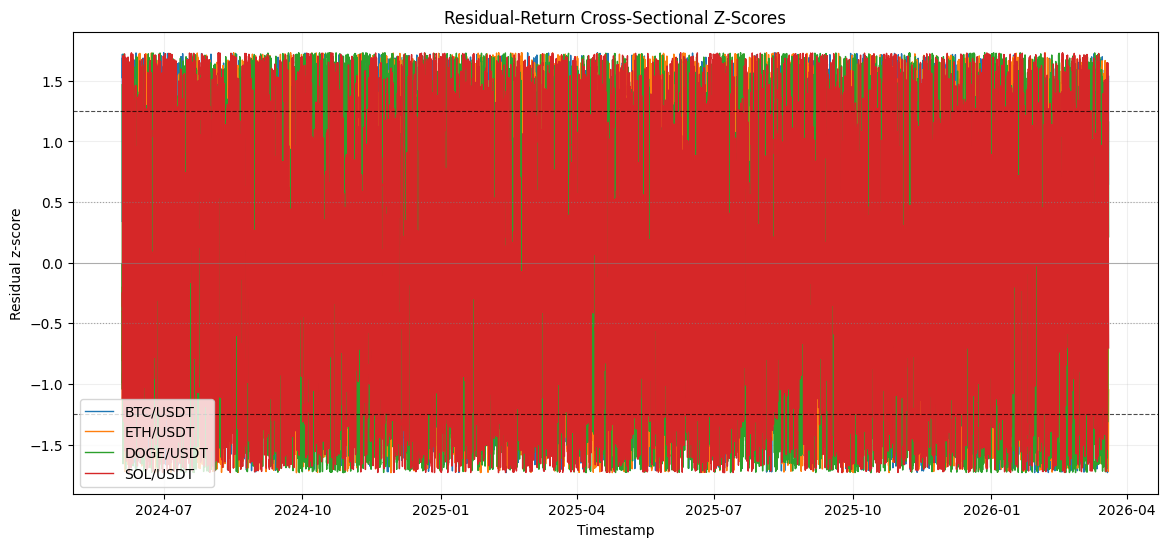

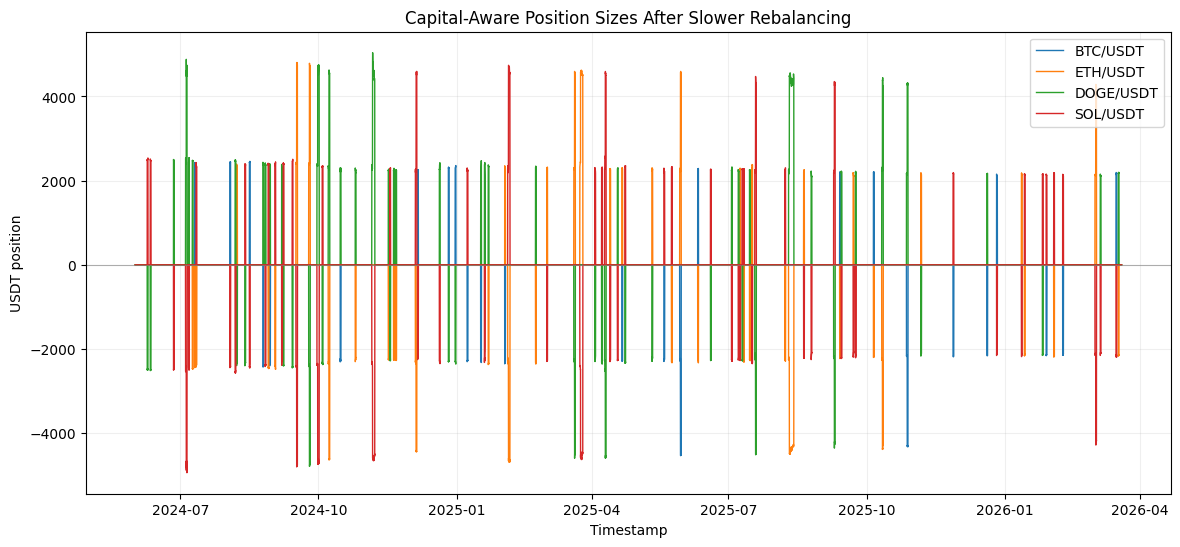

In [123]:
fig, ax = plt.subplots(figsize=(14, 6))
for symbol in ASSET_COLUMNS:
    ax.plot(zscore_df.index, zscore_df[symbol], lw=1.0, label=symbol)
ax.axhline(ENTRY_ZSCORE, color="black", lw=0.8, ls="--", alpha=0.7)
ax.axhline(-ENTRY_ZSCORE, color="black", lw=0.8, ls="--", alpha=0.7)
ax.axhline(EXIT_ZSCORE, color="grey", lw=0.8, ls=":", alpha=0.7)
ax.axhline(-EXIT_ZSCORE, color="grey", lw=0.8, ls=":", alpha=0.7)
ax.axhline(0.0, color="grey", lw=0.8, alpha=0.6)
ax.set_title("Residual-Return Cross-Sectional Z-Scores")
ax.set_ylabel("Residual z-score")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
for symbol in ASSET_COLUMNS:
    ax.plot(theta_df.index, theta_df[symbol], lw=1.0, label=symbol)
ax.axhline(0.0, color="grey", lw=0.8, alpha=0.6)
ax.set_title("Capital-Aware Position Sizes After Slower Rebalancing")
ax.set_ylabel("USDT position")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()


For convenience, the final objects from this section are `close_df`, `signal_return_df`, `pnl_return_df`, `beta_df`, `residual_return_df`, `residual_signal_df`, `zscore_df`, `signal_df`, `position_weight_df`, `theta_df`, `trade_log_df`, `gross_exposure_series`, `turnover_series`, `transaction_cost_series`, and `equity_curve_series`.


In [124]:
display(signal_df.tail())
display(position_weight_df.tail())
display(theta_df.tail())
display(trade_log_df.tail())


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 14:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 15:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 16:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 17:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 18:00:00+00:00,0.0,0.0,0.0,0.0


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 14:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 15:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 16:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 17:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 18:00:00+00:00,0.0,0.0,0.0,0.0


,BTC/USDT,ETH/USDT,DOGE/USDT,SOL/USDT
timestamp,,,,
2026-03-19 14:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 15:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 16:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 17:00:00+00:00,0.0,0.0,0.0,0.0
2026-03-19 18:00:00+00:00,0.0,0.0,0.0,0.0


,entry_time,exit_time,holding_bars,completed
90,2026-02-08 13:00:00+00:00,2026-02-09 01:00:00+00:00,12,True
91,2026-03-02 01:00:00+00:00,2026-03-03 01:00:00+00:00,24,True
92,2026-03-05 13:00:00+00:00,2026-03-06 01:00:00+00:00,12,True
93,2026-03-16 01:00:00+00:00,2026-03-16 13:00:00+00:00,12,True
94,2026-03-17 13:00:00+00:00,2026-03-18 01:00:00+00:00,12,True


The implementation remains forward-safe throughout. Residual z-scores are lagged one bar before signal generation, dispersion filters are lagged, volatilities are lagged for sizing, positions are only rebalanced on scheduled bars, and transaction costs are applied after the bar's mark-to-market move. The engine flattens permanently if equity falls through the liquidation floor.


In [125]:
print(f"Signal input column: {SIGNAL_RETURN_COLUMN}")
print(f"P&L input column: {PNL_RETURN_COLUMN}")
print(f"Rolling beta window: {BETA_WINDOW} bars")
print(f"Residual lookback: {SIGNAL_LOOKBACK} bars")
print(f"Rebalance frequency: every {REBALANCE_EVERY_BARS} bars")
print(f"Entry / exit z-score thresholds: {ENTRY_ZSCORE:.2f} / {EXIT_ZSCORE:.2f}")
print(f"Minimum hold period: {MIN_HOLD_BARS} bars")
print(f"Maximum gross leverage: {MAX_GROSS_LEVERAGE:.1f}x marked equity")
print(f"Turnover cap on risk increases: {MAX_TURNOVER_FRACTION:.2f}x allowed gross")
print(f"Transaction cost assumption: {TRANSACTION_COST_BPS:.1f} bps per unit turnover")
print(f"Liquidation equity floor: {LIQUIDATION_EQUITY_FLOOR_USDT:,.0f} USDT")
print(f"Maximum observed gross exposure: {gross_exposure_series.max():,.2f} USDT")
print(f"Minimum observed equity: {equity_curve_series.min():,.2f} USDT")
print(f"Liquidated during backtest: {'Yes' if liquidated else 'No'}")


Signal input column: clean_return
P&L input column: clean_return
Rolling beta window: 168 bars
Residual lookback: 6 bars
Rebalance frequency: every 12 bars
Entry / exit z-score thresholds: 1.25 / 0.50
Minimum hold period: 6 bars
Maximum gross leverage: 1.0x marked equity
Turnover cap on risk increases: 0.50x allowed gross
Transaction cost assumption: 10.0 bps per unit turnover
Liquidation equity floor: 2,500 USDT
Maximum observed gross exposure: 9,762.65 USDT
Minimum observed equity: 8,531.93 USDT
Liquidated during backtest: No


### Trading Results

The results below now separate gross alpha from the drag created by trading costs and report whether the lower-turnover design actually survives under realistic funding constraints. This makes it easier to see whether any improvement comes from better signal quality, lower churn, or simply smaller risk.


In [126]:
strategy_summary = summarize_strategy_state(
    strategy_state,
    initial_capital_usdt=INITIAL_CAPITAL_USDT,
    hours_per_year=HOURS_PER_YEAR,
)

results_summary = pd.DataFrame(
    {
        "metric": [
            "Ending equity (USDT)",
            "Total gross PnL before costs (USDT)",
            "Total transaction costs (USDT)",
            "Total net PnL (USDT)",
            "Total return (%)",
            "Annualized gross return (%)",
            "Annualized gross volatility (%)",
            "Gross Sharpe ratio",
            "Annualized net return (%)",
            "Annualized net volatility (%)",
            "Net Sharpe ratio",
            "Max drawdown (%)",
            "Active-bar win rate (%)",
            "Average gross exposure (USDT)",
            "Average exposure utilization",
            "Average gross leverage (x)",
            "Average turnover per rebalance (USDT)",
            "Trade count",
            "Average holding period (bars)",
            "Minimum equity (USDT)",
            "Liquidated during backtest",
        ],
        "value": [
            strategy_summary["ending_equity"],
            strategy_summary["total_gross_pnl"],
            strategy_summary["total_transaction_costs"],
            strategy_summary["total_net_pnl"],
            strategy_summary["total_return_pct"],
            strategy_summary["annualized_gross_return_pct"],
            strategy_summary["annualized_gross_vol_pct"],
            strategy_summary["gross_sharpe"],
            strategy_summary["annualized_net_return_pct"],
            strategy_summary["annualized_net_vol_pct"],
            strategy_summary["net_sharpe"],
            strategy_summary["max_drawdown_pct"],
            strategy_summary["active_bar_win_rate_pct"],
            strategy_summary["average_gross_exposure"],
            strategy_summary["average_exposure_utilization"],
            strategy_summary["average_gross_leverage"],
            strategy_summary["average_turnover_per_rebalance"],
            strategy_summary["trade_count"],
            strategy_summary["average_holding_bars"],
            strategy_summary["minimum_equity"],
            "Yes" if strategy_summary["liquidated"] else "No",
        ],
    }
)

display(results_summary)
display(
    pd.concat(
        [
            gross_pnl_series,
            portfolio_pnl_series,
            transaction_cost_series,
            turnover_series,
            equity_curve_series,
            drawdown_series,
        ],
        axis=1,
    ).tail()
)


,metric,value
0,Ending equity (USDT),8619.535837
1,Total gross PnL before costs (USDT),-345.947799
2,Total transaction costs (USDT),1034.516364
3,Total net PnL (USDT),-1380.464163
4,Total return (%),-13.804642
5,Annualized gross return (%),-1.719578
6,Annualized gross volatility (%),7.127667
7,Gross Sharpe ratio,-0.241254
8,Annualized net return (%),-7.999507
9,Annualized net volatility (%),7.174531


,gross_pnl,portfolio_pnl,transaction_cost,turnover,equity_curve,drawdown
timestamp,,,,,,
2026-03-19 14:00:00+00:00,0.0,0.0,0.0,0.0,8619.535837,-0.141324
2026-03-19 15:00:00+00:00,0.0,0.0,0.0,0.0,8619.535837,-0.141324
2026-03-19 16:00:00+00:00,0.0,0.0,0.0,0.0,8619.535837,-0.141324
2026-03-19 17:00:00+00:00,0.0,0.0,0.0,0.0,8619.535837,-0.141324
2026-03-19 18:00:00+00:00,0.0,0.0,0.0,0.0,8619.535837,-0.141324


The charts below compare the gross and net equity paths and then show the realized drawdown after costs. This makes the cost drag from turnover visible rather than hiding it inside a single equity series.


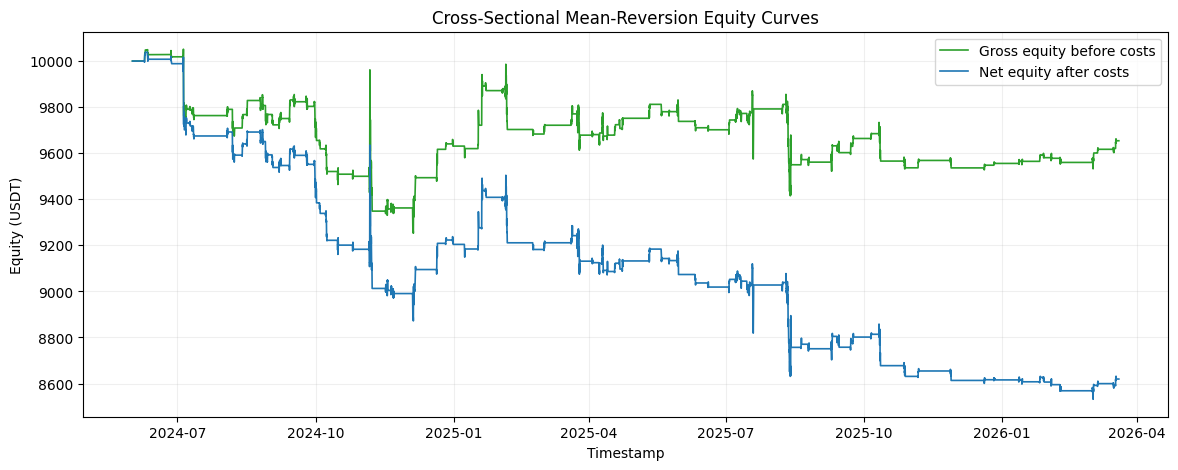

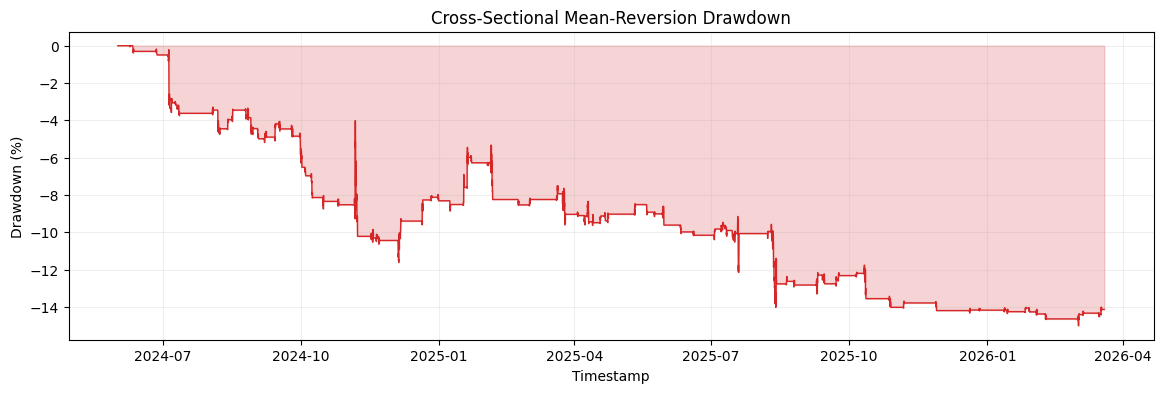

In [127]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gross_equity_curve_series.index, gross_equity_curve_series, color="tab:green", lw=1.2, label="Gross equity before costs")
ax.plot(equity_curve_series.index, equity_curve_series, color="tab:blue", lw=1.2, label="Net equity after costs")
ax.set_title("Cross-Sectional Mean-Reversion Equity Curves")
ax.set_ylabel("Equity (USDT)")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(drawdown_series.index, 100.0 * drawdown_series, color="tab:red", lw=1.0)
ax.fill_between(drawdown_series.index, 100.0 * drawdown_series, 0.0, color="tab:red", alpha=0.2)
ax.set_title("Cross-Sectional Mean-Reversion Drawdown")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Timestamp")
ax.grid(alpha=0.2)
plt.show()


### Parameter Sweep


This sweep keeps the same residual-reversal engine and cost assumptions, then varies only the rebalance interval, entry threshold, and minimum hold period. The goal is to see whether lower turnover is enough to rescue the idea or whether the alpha remains weak even after slowing the strategy down.


In [128]:
parameter_sweep_rows = []

for rebalance_every_bars, entry_zscore, min_hold_bars in product([6, 12, 24], [1.25, 1.50, 1.75], [6, 12]):
    sweep_state = run_cross_sectional_strategy(
        close_df=close_df,
        signal_return_df=signal_return_df,
        pnl_return_df=pnl_return_df,
        zscore_df=zscore_df,
        cross_sectional_dispersion_series=cross_sectional_dispersion_series,
        dispersion_floor_series=dispersion_floor_series,
        entry_zscore=entry_zscore,
        exit_zscore=0.50,
        rebalance_every_bars=rebalance_every_bars,
        min_hold_bars=min_hold_bars,
        top_k=TOP_K,
        vol_window=VOL_WINDOW,
        initial_capital_usdt=INITIAL_CAPITAL_USDT,
        gross_exposure_cap_usdt=GROSS_EXPOSURE_CAP_USDT,
        max_gross_leverage=MAX_GROSS_LEVERAGE,
        transaction_cost_bps=TRANSACTION_COST_BPS,
        max_turnover_fraction=MAX_TURNOVER_FRACTION,
        liquidation_equity_floor_usdt=LIQUIDATION_EQUITY_FLOOR_USDT,
    )

    sweep_summary = summarize_strategy_state(
        sweep_state,
        initial_capital_usdt=INITIAL_CAPITAL_USDT,
        hours_per_year=HOURS_PER_YEAR,
    )
    parameter_sweep_rows.append(
        {
            "rebalance_every_bars": rebalance_every_bars,
            "entry_zscore": entry_zscore,
            "exit_zscore": 0.50,
            "min_hold_bars": min_hold_bars,
            "ending_equity": sweep_summary["ending_equity"],
            "total_net_pnl": sweep_summary["total_net_pnl"],
            "total_transaction_costs": sweep_summary["total_transaction_costs"],
            "net_sharpe": sweep_summary["net_sharpe"],
            "max_drawdown_pct": sweep_summary["max_drawdown_pct"],
            "average_turnover_per_rebalance": sweep_summary["average_turnover_per_rebalance"],
            "trade_count": sweep_summary["trade_count"],
            "liquidated": sweep_summary["liquidated"],
        }
    )

parameter_sweep_df = pd.DataFrame(parameter_sweep_rows).sort_values(
    ["net_sharpe", "ending_equity"],
    ascending=[False, False],
).reset_index(drop=True)

display(parameter_sweep_df)


,rebalance_every_bars,entry_zscore,exit_zscore,min_hold_bars,ending_equity,total_net_pnl,total_transaction_costs,net_sharpe,max_drawdown_pct,average_turnover_per_rebalance,trade_count,liquidated
0,12,1.25,0.5,6,8619.535837,-1380.464163,1034.516364,-1.114987,-15.005105,784.291131,95,False
1,12,1.25,0.5,12,8619.535837,-1380.464163,1034.516364,-1.114987,-15.005105,784.291131,95,False
2,6,1.25,0.5,6,8248.788880,-1751.211120,2236.985825,-1.138324,-20.350721,848.516229,204,False
3,24,1.25,0.5,6,8558.590443,-1441.409557,547.148556,-1.241753,-16.466071,825.378747,47,False
4,24,1.25,0.5,12,8558.590443,-1441.409557,547.148556,-1.241753,-16.466071,825.378747,47,False
5,6,1.25,0.5,12,6278.955809,-3721.044191,2909.448461,-1.970563,-39.312824,1099.594491,188,False
6,6,1.50,0.5,6,10000.000000,0.000000,0.000000,NaN,0.000000,0.000000,0,False
7,6,1.50,0.5,12,10000.000000,0.000000,0.000000,NaN,0.000000,0.000000,0,False
8,6,1.75,0.5,6,10000.000000,0.000000,0.000000,NaN,0.000000,0.000000,0,False
9,6,1.75,0.5,12,10000.000000,0.000000,0.000000,NaN,0.000000,0.000000,0,False
